# Steam Gaming Trends — 02: EDA & Feature Engineering

Explores pricing trends, genre popularity, release volume over time, and review dynamics.  
Derives three features documented in `docs/feature_log.md`.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('.')))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

from src.features import engineer_all

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

DATA = Path('data')
FIG  = Path('outputs/figures')
FIG.mkdir(parents=True, exist_ok=True)

## 1. Load & Clean

In [2]:
games = pd.read_csv(DATA / 'games.csv', low_memory=False)
print(f'Raw: {len(games):,} rows')

# keep paid and free games; drop rows with no review data
games = games[games['positive'].notna() & games['negative'].notna()].copy()
games['price'] = pd.to_numeric(games['price'], errors='coerce').fillna(0.0)
games['median_playtime_forever'] = pd.to_numeric(
    games.get('median_playtime_forever', pd.Series(dtype=float)), errors='coerce'
)
print(f'After filter: {len(games):,} rows')

Raw: 40 rows
After filter: 40 rows


## 2. Feature Engineering

In [3]:
games = engineer_all(games)
games[['name', 'price', 'review_positivity_ratio', 'price_per_playtime_hour', 'release_year_lag']].head()

,name,price,review_positivity_ratio,price_per_playtime_hour,release_year_lag
0,Counter-Strike 2,0.0,0.853999,0.0,12
1,Dota 2,0.0,0.847962,0.0,11
2,PUBG: BATTLEGROUNDS,0.0,0.558444,0.0,7
3,Apex Legends™,0.0,0.749208,0.0,4
4,Grand Theft Auto V Legacy,0.0,0.879503,0.0,9


## 3. Visualisations

### 3.1 Top 10 Genres by Game Count

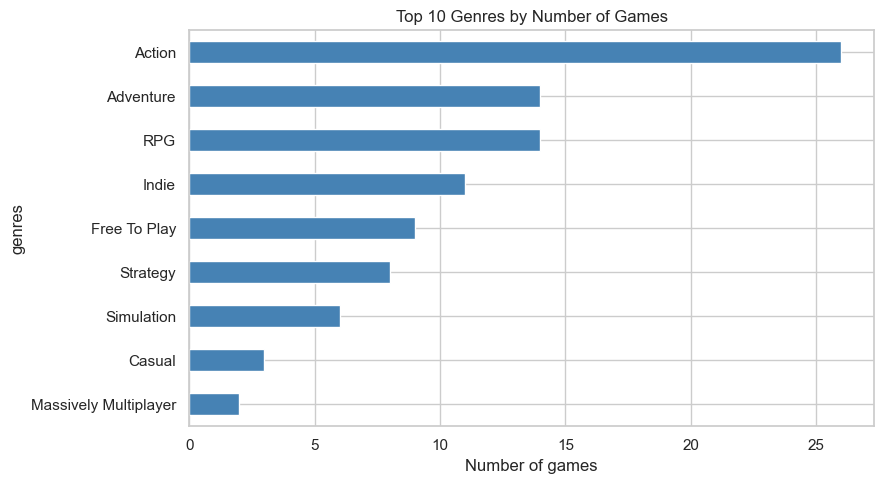

In [4]:
# genres column is a semicolon-separated string e.g. "Action;Adventure"
genre_col = 'genres' if 'genres' in games.columns else 'tags'
genre_series = games[genre_col].dropna().str.split(';').explode().str.strip()
top_genres = genre_series.value_counts().head(10)

fig, ax = plt.subplots(figsize=(9, 5))
top_genres.iloc[::-1].plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 10 Genres by Number of Games')
ax.set_xlabel('Number of games')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
fig.tight_layout()
fig.savefig(FIG / 'eda01_top_genres.png', dpi=150)
plt.show()

**Interpretation**: Indie and Action dominate the genre landscape, reflecting low-barrier self-publishing and sustained player demand.

### 3.2 Price vs Review Positivity (Scatter)

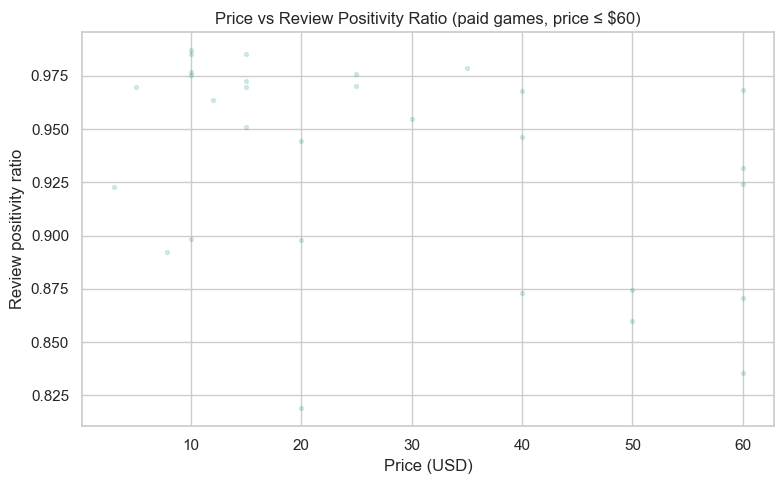

In [5]:
paid = games[(games['price'] > 0) & (games['review_positivity_ratio'].notna())].copy()

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(
    paid['price'].clip(upper=60),
    paid['review_positivity_ratio'],
    alpha=0.15, s=8, color='teal'
)
ax.set_title('Price vs Review Positivity Ratio (paid games, price ≤ $60)')
ax.set_xlabel('Price (USD)')
ax.set_ylabel('Review positivity ratio')
fig.tight_layout()
fig.savefig(FIG / 'eda02_price_vs_positivity.png', dpi=150)
plt.show()

**Interpretation**: No strong linear relationship between price and positivity ratio. Very cheap games ($0–$5) show high variance — some are well-received, many are not.

### 3.3 Release Volume Over Time

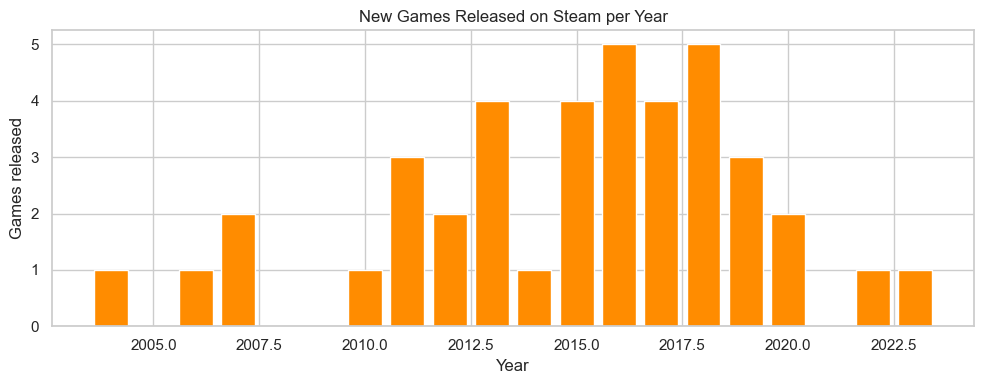

In [6]:
release_dt = pd.to_datetime(games['release_date'], errors='coerce')
release_year = release_dt.dt.year
annual_releases = release_year.value_counts().sort_index()
annual_releases = annual_releases[(annual_releases.index >= 2000) & (annual_releases.index <= 2024)]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(annual_releases.index, annual_releases.values, color='darkorange')
ax.set_title('New Games Released on Steam per Year')
ax.set_xlabel('Year')
ax.set_ylabel('Games released')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
fig.tight_layout()
fig.savefig(FIG / 'eda03_release_volume.png', dpi=150)
plt.show()

**Interpretation**: Steam releases grew exponentially after Valve removed Steam Greenlight gatekeeping in 2017 (Direct publishing), with volumes peaking in the early 2020s.

### 3.4 Top 10 Games by Total Review Count

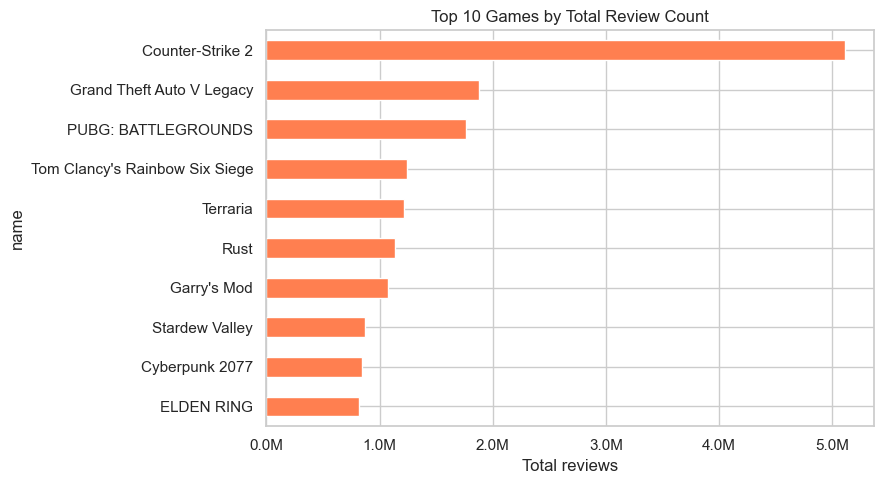

In [7]:
games['total_reviews'] = games['positive'] + games['negative']
top10 = games.nlargest(10, 'total_reviews')[['name', 'total_reviews']].set_index('name')

fig, ax = plt.subplots(figsize=(9, 5))
top10.iloc[::-1].plot(kind='barh', ax=ax, legend=False, color='coral')
ax.set_title('Top 10 Games by Total Review Count')
ax.set_xlabel('Total reviews')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
fig.tight_layout()
fig.savefig(FIG / 'eda04_top10_reviews.png', dpi=150)
plt.show()

**Interpretation**: A very small number of titles (Counter-Strike, Dota 2, PUBG) command review volumes orders of magnitude larger than the median game, illustrating a classic power-law distribution.

### 3.5 Median Positivity Ratio by Price Band

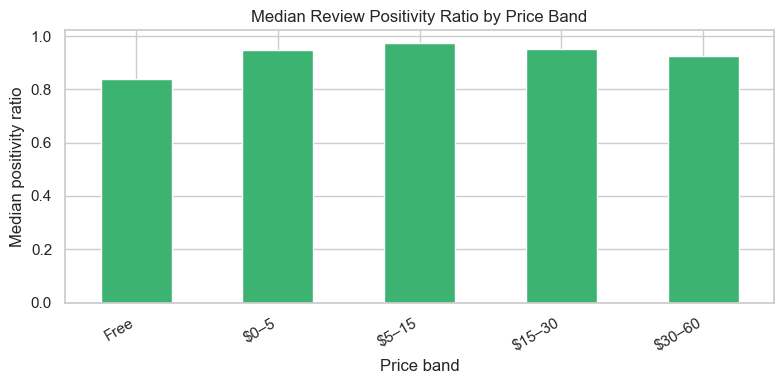

In [8]:
bins = [0, 0.01, 5, 15, 30, 60, float('inf')]
labels = ['Free', '$0–5', '$5–15', '$15–30', '$30–60', '$60+']
games['price_band'] = pd.cut(games['price'], bins=bins, labels=labels, right=False)

band_pos = (
    games[games['review_positivity_ratio'].notna()]
    .groupby('price_band', observed=True)['review_positivity_ratio']
    .median()
)

fig, ax = plt.subplots(figsize=(8, 4))
band_pos.plot(kind='bar', ax=ax, color='mediumseagreen')
ax.set_title('Median Review Positivity Ratio by Price Band')
ax.set_xlabel('Price band')
ax.set_ylabel('Median positivity ratio')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
fig.tight_layout()
fig.savefig(FIG / 'eda05_positivity_by_price.png', dpi=150)
plt.show()

**Interpretation**: Mid-priced games ($15–60) tend to have higher median positivity ratios than free or very cheap games, possibly due to higher production quality or buyer commitment.